# SPEAR3 HVPS Analytical Design Math Technical Notebook

This notebook is a standalone technical note for the SPEAR3 legacy high-voltage power supply. It converts the analytical design math from the HVPS design report into executable calculations, engineering tables, and plots that show how the system behaves from the three-phase AC input through rectification, filtering, protection, and klystron loading.

Notebook objectives:
- Recreate the 3-phase to 12-pulse rectifier waveform construction
- Verify the documented DC output and firing-angle relationships
- Quantify ripple, filtering, beam current, protection energy, and power quality
- Add an engineering ramp-up model from 0 kV to the 77 kV operating point
- Generate representative versions of the four B118 monitoring channels used in the real system

This notebook uses the equations documented in the HVPS report and clearly marks any synthetic diagnostic waveforms as engineering reconstructions rather than archived measurements.

## System Overview and Governing Equations

The legacy SPEAR3 HVPS is a 12-pulse controlled rectifier system that converts 12.47 kV, 60 Hz three-phase utility power into a regulated negative cathode supply for the klystron. The physical conversion chain is:

$12.47\ \mathrm{kV}_{LL,\ rms}\ 3\phi \rightarrow T_0\ (\pm 15^\circ) \rightarrow T_1,T_2\ \rightarrow 2\times 6\text{-pulse bridges} \rightarrow 12\text{-pulse DC} \rightarrow LC\ \text{filter} \rightarrow -77\ \mathrm{kV}\ \text{to klystron}$

The notebook is organized around the core governing equations for that chain.

Three-phase to line-line conversion:

$$
\begin{aligned}
v_a &= V_m\sin(\omega t), \\
v_b &= V_m\sin(\omega t - 120^\circ), \\
v_c &= V_m\sin(\omega t + 120^\circ)
\end{aligned}
$$

$$
v_{ab} = v_a - v_b = \sqrt{2}V_{LL}\cos(\omega t - 60^\circ)
$$

Average 12-pulse DC output:

$$
V_{dc} = \frac{6\sqrt{2}}{\pi}V_{LL}\cos\alpha \approx 2.70\,V_{LL}\cos\alpha
$$

Klystron beam-current model:

$$
I_{beam} = P_k V_{cathode}^{3/2}
$$

Ripple and filter estimates:

$$
\frac{\Delta V_{pp}}{V_{max}} = 1 - \cos(15^\circ), \qquad f_{ripple} = 12f_{line} = 720\ \mathrm{Hz}
$$

Stored-energy expressions used in the protection analysis:

$$
E_C = \tfrac{1}{2}CV^2, \qquad E_L = \tfrac{1}{2}LI^2
$$

The results later in the notebook connect these equations to the main system observables: output voltage, output current, primary current, ripple, protection energy, and the four diagnostic channels monitored from Building 118.

## System Block Diagram Mapped to the Equation Sections

This figure ties the physical HVPS subsystems to the analytical sections that follow. It is intended as a navigation diagram for the notebook: each block corresponds to a part of the power-conversion chain and to a set of governing equations or engineering estimates developed in the later sections.

The mapping is:

- Three-phase source and transformer phase shift: three-phase and line-line voltage derivations
- 6-pulse bridge pair and 12-pulse sum: rectifier envelope and average output equations
- Ramp and regulation: firing-angle and working-point calculations
- Klystron load: perveance, beam current, and power
- Filter and protection: ripple attenuation, capacitor energy, inductor energy, and RC discharge
- Diagnostics: B118 monitor channels for voltage, current, transformer current, and inductor voltage

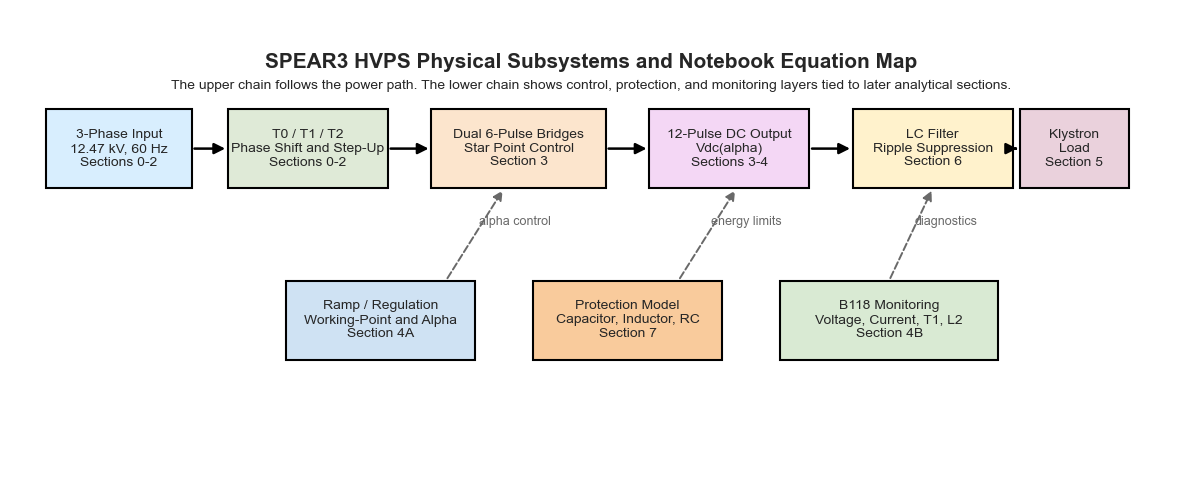

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 16)
ax.set_ylim(0, 7)
ax.axis('off')

blocks = [
    (0.5, 4.3, 2.0, 1.2, '3-Phase Input\n12.47 kV, 60 Hz\nSections 0-2', '#d8eefe'),
    (3.0, 4.3, 2.2, 1.2, 'T0 / T1 / T2\nPhase Shift and Step-Up\nSections 0-2', '#dfead7'),
    (5.8, 4.3, 2.4, 1.2, 'Dual 6-Pulse Bridges\nStar Point Control\nSection 3', '#fce5cd'),
    (8.8, 4.3, 2.2, 1.2, '12-Pulse DC Output\nVdc(alpha)\nSections 3-4', '#f4d7f5'),
    (11.6, 4.3, 2.2, 1.2, 'LC Filter\nRipple Suppression\nSection 6', '#fff2cc'),
    (13.9, 4.3, 1.5, 1.2, 'Klystron\nLoad\nSection 5', '#ead1dc'),
    (3.8, 1.7, 2.6, 1.2, 'Ramp / Regulation\nWorking-Point and Alpha\nSection 4A', '#cfe2f3'),
    (7.2, 1.7, 2.6, 1.2, 'Protection Model\nCapacitor, Inductor, RC\nSection 7', '#f9cb9c'),
    (10.6, 1.7, 3.0, 1.2, 'B118 Monitoring\nVoltage, Current, T1, L2\nSection 4B', '#d9ead3'),
]

for x0, y0, width, height, label, color in blocks:
    ax.add_patch(Rectangle((x0, y0), width, height, facecolor=color, edgecolor='black', linewidth=1.5))
    ax.text(x0 + width / 2, y0 + height / 2, label, ha='center', va='center', fontsize=10)

main_arrows = [
    ((2.5, 4.9), (3.0, 4.9)),
    ((5.2, 4.9), (5.8, 4.9)),
    ((8.2, 4.9), (8.8, 4.9)),
    ((11.0, 4.9), (11.6, 4.9)),
    ((13.8, 4.9), (13.9, 4.9)),
]
for start, end in main_arrows:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=16, linewidth=1.8, color='black'))

cross_links = [
    ((6.0, 2.9), (6.8, 4.3), 'alpha control'),
    ((9.2, 2.9), (10.0, 4.3), 'energy limits'),
    ((12.1, 2.9), (12.7, 4.3), 'diagnostics'),
]
for start, end, text in cross_links:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=14, linewidth=1.4, linestyle='--', color='dimgray'))
    ax.text((start[0] + end[0]) / 2 + 0.05, (start[1] + end[1]) / 2 + 0.15, text, fontsize=9, color='dimgray')

ax.text(8.0, 6.2, 'SPEAR3 HVPS Physical Subsystems and Notebook Equation Map', ha='center', va='center', fontsize=15, weight='bold')
ax.text(8.0, 5.85, 'The upper chain follows the power path. The lower chain shows control, protection, and monitoring layers tied to later analytical sections.', ha='center', va='center', fontsize=10)

plt.show()

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

## 1. System Constants and Helper Functions

The report uses a 12.47 kV, 60 Hz input, a 33.3 kV secondary line-to-line voltage, a 90 kV maximum DC output, and a nominal operating point near 77 kV. This cell defines the shared constants and helper functions used throughout the notebook.

In [20]:
DEG = np.pi / 180.0

system = {
    'f_line_hz': 60.0,
    'v_input_ll_rms': 12.47e3,
    'v_t1_primary_ll_rms': 12.5e3,
    'v_secondary_ll_rms': 33.3e3,
    'vdc_max': 90.0e3,
    'vdc_nominal': 77.0e3,
    'idc_nominal': 22.0,
    'vdc_measured': 72.08e3,
    'idc_measured': 19.4,
    'cap_filter_f': 8e-6,
    'isolation_res_ohm': 500.0,
    'inductor_primary_h': 0.3,
    'inductor_primary_rated_a': 85.0,
    'cable_inductor_h': 200e-6,
    'power_factor_distortion_12pulse': 0.9886,
}

def phase_voltages(theta_rad, v_phase_peak):
    va = v_phase_peak * np.sin(theta_rad)
    vb = v_phase_peak * np.sin(theta_rad - 2 * np.pi / 3)
    vc = v_phase_peak * np.sin(theta_rad + 2 * np.pi / 3)
    return va, vb, vc

def line_to_line_from_phases(va, vb, vc):
    return {
        'v_cb': vc - vb,
        'v_ab': va - vb,
        'v_ac': va - vc,
        'v_bc': vb - vc,
        'v_ba': vb - va,
        'v_ca': vc - va,
    }

def six_pulse_bridge(theta_rad, v_ll_rms, phase_shift_deg=0.0):
    phases_deg = np.array([0, 60, 120, 180, 240, 300], dtype=float) + phase_shift_deg
    waveforms = np.array([np.sqrt(2) * v_ll_rms * np.cos(theta_rad - phase * DEG) for phase in phases_deg])
    envelope = waveforms.max(axis=0)
    return waveforms, envelope, phases_deg

def vdc_6pulse(v_ll_rms, alpha_deg):
    return (3 * np.sqrt(2) / np.pi) * v_ll_rms * np.cos(alpha_deg * DEG)

def vdc_12pulse(v_ll_rms, alpha_deg):
    return (6 * np.sqrt(2) / np.pi) * v_ll_rms * np.cos(alpha_deg * DEG)

def firing_angle_from_vdc(vdc, v_ll_rms):
    ratio = np.clip(vdc / ((6 * np.sqrt(2) / np.pi) * v_ll_rms), -1.0, 1.0)
    return np.degrees(np.arccos(ratio))

def beam_current_from_perveance(vdc_volts, perveance_a_per_v32=1.0e-6):
    return perveance_a_per_v32 * np.power(vdc_volts, 1.5)

def harmonic_orders_12pulse(max_order=37):
    orders = []
    for order in range(1, max_order + 1):
        if order > 1 and order % 12 in (1, 11):
            orders.append(order)
    return np.array(orders, dtype=int)


## 2. Three-Phase Input and Six Line-to-Line Voltages

The derivation starts with the three phase voltages and constructs the six line-to-line voltages that a 6-pulse bridge selects from. The plot below shows one electrical cycle at the 33.3 kV secondary level used in the analytical section.

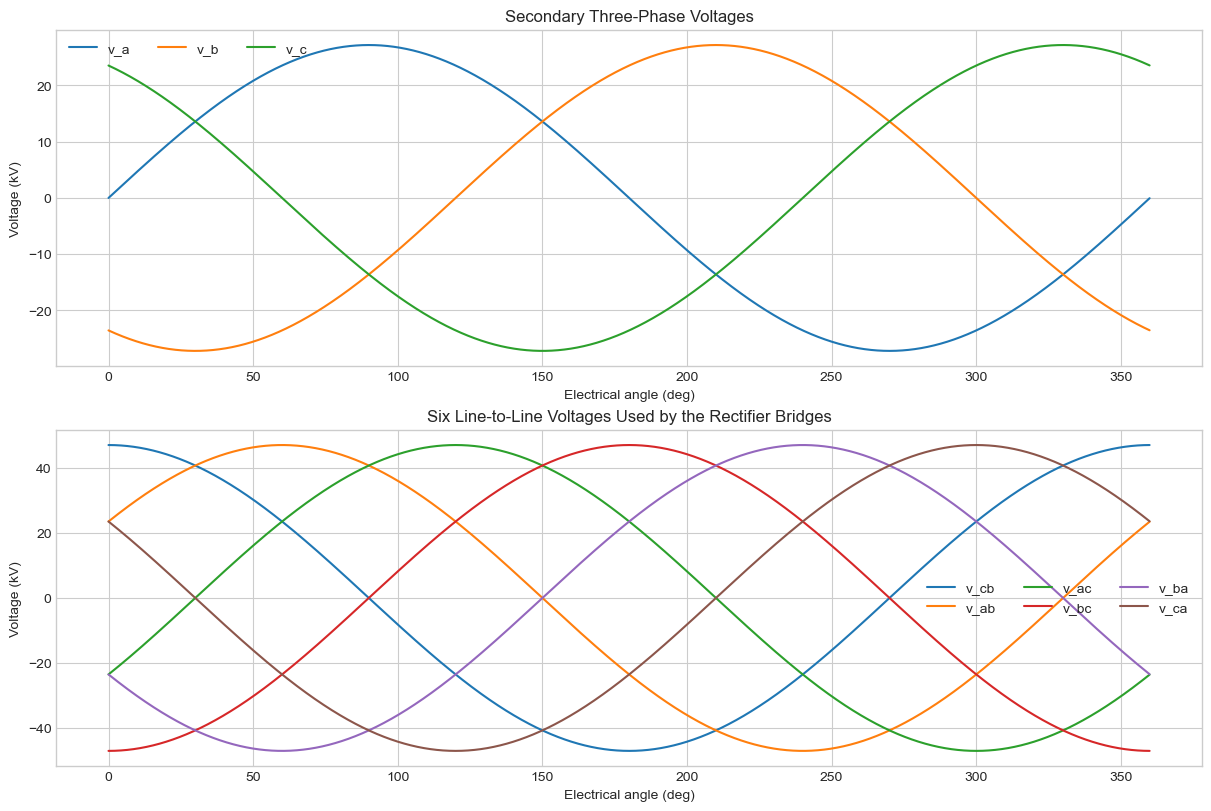

In [21]:
theta = np.linspace(0, 2 * np.pi, 4000, endpoint=False)
theta_deg = np.degrees(theta)
v_phase_rms = system['v_secondary_ll_rms'] / np.sqrt(3)
v_phase_peak = np.sqrt(2) * v_phase_rms
va, vb, vc = phase_voltages(theta, v_phase_peak)
ll = line_to_line_from_phases(va, vb, vc)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
axes[0].plot(theta_deg, va / 1e3, label='v_a')
axes[0].plot(theta_deg, vb / 1e3, label='v_b')
axes[0].plot(theta_deg, vc / 1e3, label='v_c')
axes[0].set_title('Secondary Three-Phase Voltages')
axes[0].set_xlabel('Electrical angle (deg)')
axes[0].set_ylabel('Voltage (kV)')
axes[0].legend(ncol=3)

for name, values in ll.items():
    axes[1].plot(theta_deg, values / 1e3, label=name)
axes[1].set_title('Six Line-to-Line Voltages Used by the Rectifier Bridges')
axes[1].set_xlabel('Electrical angle (deg)')
axes[1].set_ylabel('Voltage (kV)')
axes[1].legend(ncol=3)
plt.show()

## 3. Single 6-Pulse Bridge Envelope and Two-Bridge 12-Pulse Combination

Bridge X selects the highest of six cosine-shifted line-line waveforms, which creates the familiar 60 degree envelope segments. Bridge Y is shifted by 30 degrees, and the two bridge outputs sum in series to create the 12-pulse waveform.

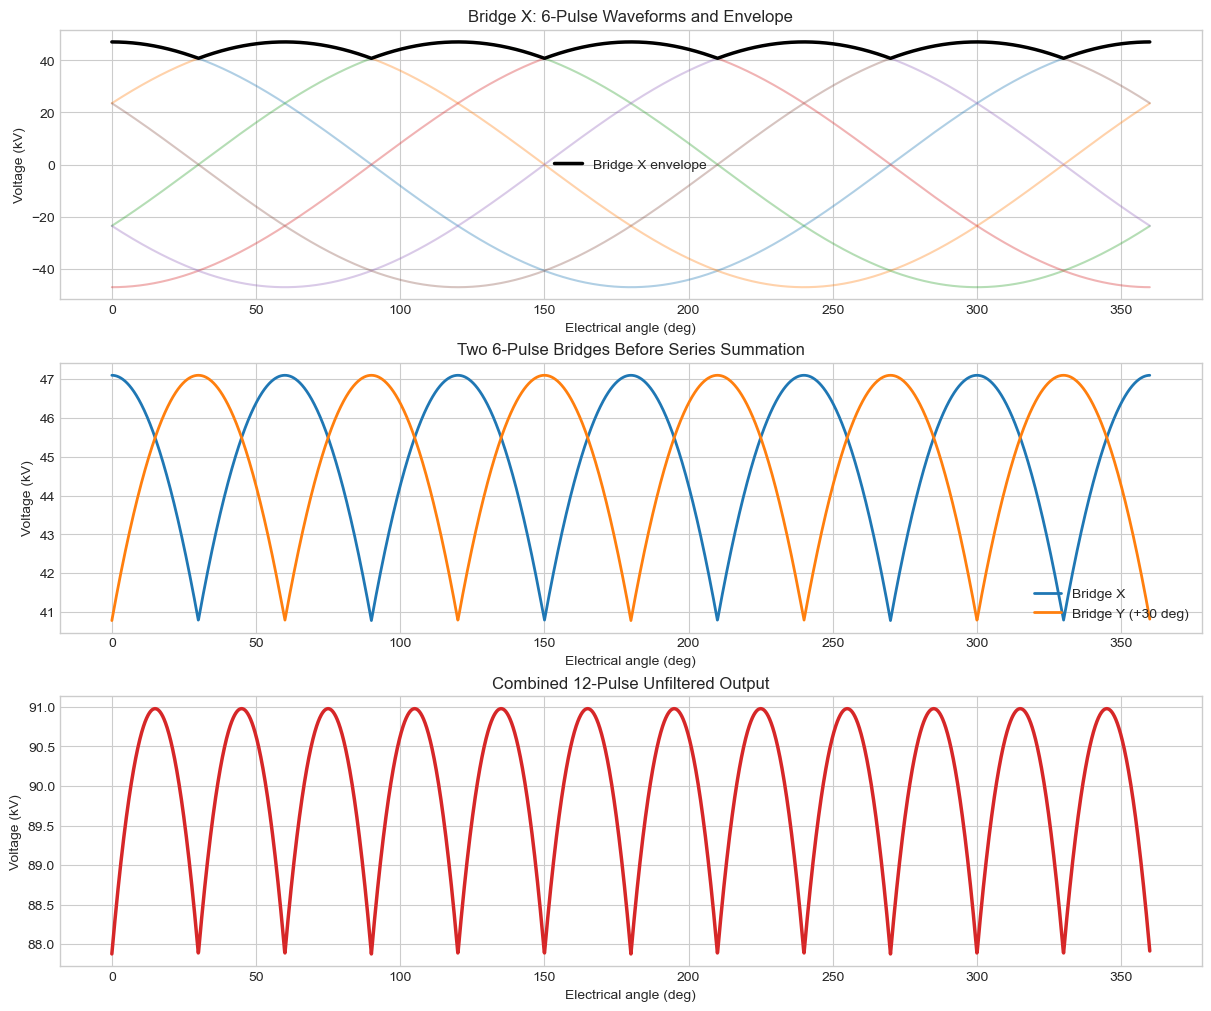

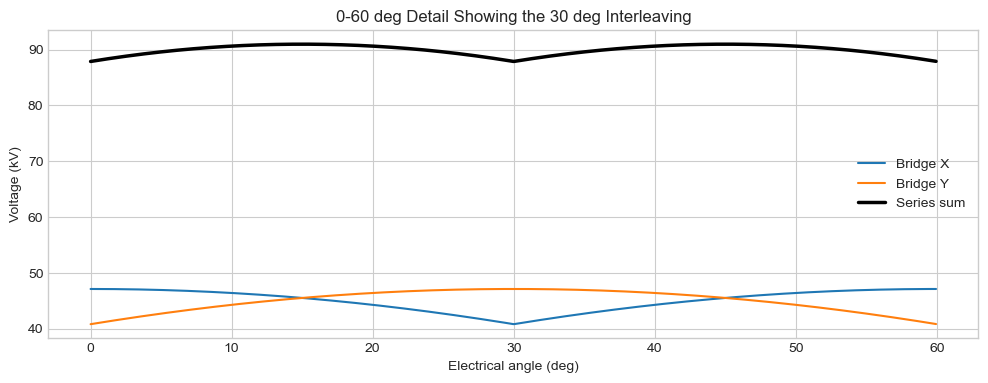

In [22]:
bridge_x_waves, bridge_x_env, phases_x = six_pulse_bridge(theta, system['v_secondary_ll_rms'], phase_shift_deg=0.0)
bridge_y_waves, bridge_y_env, phases_y = six_pulse_bridge(theta, system['v_secondary_ll_rms'], phase_shift_deg=30.0)
bridge_sum = bridge_x_env + bridge_y_env

fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)
for idx, phase in enumerate(phases_x):
    axes[0].plot(theta_deg, bridge_x_waves[idx] / 1e3, alpha=0.35)
axes[0].plot(theta_deg, bridge_x_env / 1e3, color='black', linewidth=2.5, label='Bridge X envelope')
axes[0].set_title('Bridge X: 6-Pulse Waveforms and Envelope')
axes[0].set_xlabel('Electrical angle (deg)')
axes[0].set_ylabel('Voltage (kV)')
axes[0].legend()

axes[1].plot(theta_deg, bridge_x_env / 1e3, label='Bridge X', linewidth=2)
axes[1].plot(theta_deg, bridge_y_env / 1e3, label='Bridge Y (+30 deg)', linewidth=2)
axes[1].set_title('Two 6-Pulse Bridges Before Series Summation')
axes[1].set_xlabel('Electrical angle (deg)')
axes[1].set_ylabel('Voltage (kV)')
axes[1].legend()

axes[2].plot(theta_deg, bridge_sum / 1e3, color='tab:red', linewidth=2.5)
axes[2].set_title('Combined 12-Pulse Unfiltered Output')
axes[2].set_xlabel('Electrical angle (deg)')
axes[2].set_ylabel('Voltage (kV)')
plt.show()

window = (theta_deg >= 0) & (theta_deg <= 60)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(theta_deg[window], bridge_x_env[window] / 1e3, label='Bridge X')
ax.plot(theta_deg[window], bridge_y_env[window] / 1e3, label='Bridge Y')
ax.plot(theta_deg[window], bridge_sum[window] / 1e3, label='Series sum', linewidth=2.5, color='black')
ax.set_title('0-60 deg Detail Showing the 30 deg Interleaving')
ax.set_xlabel('Electrical angle (deg)')
ax.set_ylabel('Voltage (kV)')
ax.legend()
plt.show()

## 4. Average DC Output Versus Firing Angle

The report derives the 12-pulse DC average as $V_{dc} = \frac{6\sqrt{2}}{\pi} V_{LL} \cos(\alpha)$. This section verifies the nominal and measured operating points against that formula and visualizes the full firing-angle sweep.

,Case,Vdc_kV,Alpha_deg,cos(alpha)
0,Maximum,90.0000,0.0000,1.0000
1,Nominal,77.0000,31.1173,0.8561
2,Measured June 2020,72.0800,36.7351,0.8014


Transformer turns ratio (secondary line-line / primary line-line): 2.664:1


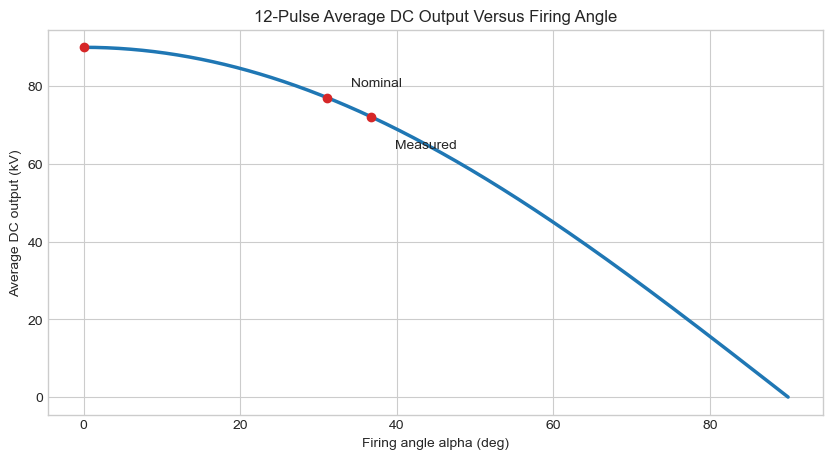

In [23]:
alpha_deg = np.linspace(0, 90, 721)
vdc_curve = vdc_12pulse(system['v_secondary_ll_rms'], alpha_deg)

alpha_nom = firing_angle_from_vdc(system['vdc_nominal'], system['v_secondary_ll_rms'])
alpha_meas = firing_angle_from_vdc(system['vdc_measured'], system['v_secondary_ll_rms'])
turns_ratio = system['v_secondary_ll_rms'] / system['v_t1_primary_ll_rms']

operating_points = pd.DataFrame({
    'Case': ['Maximum', 'Nominal', 'Measured June 2020'],
    'Vdc_kV': [system['vdc_max'] / 1e3, system['vdc_nominal'] / 1e3, system['vdc_measured'] / 1e3],
    'Alpha_deg': [0.0, alpha_nom, alpha_meas],
    'cos(alpha)': [1.0, np.cos(alpha_nom * DEG), np.cos(alpha_meas * DEG)],
})
display(operating_points)
print(f'Transformer turns ratio (secondary line-line / primary line-line): {turns_ratio:.3f}:1')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alpha_deg, vdc_curve / 1e3, linewidth=2.5)
ax.scatter([0.0, alpha_nom, alpha_meas], [system['vdc_max'] / 1e3, system['vdc_nominal'] / 1e3, system['vdc_measured'] / 1e3], color='tab:red', zorder=3)
ax.annotate('Nominal', (alpha_nom, system['vdc_nominal'] / 1e3), xytext=(alpha_nom + 3, system['vdc_nominal'] / 1e3 + 3))
ax.annotate('Measured', (alpha_meas, system['vdc_measured'] / 1e3), xytext=(alpha_meas + 3, system['vdc_measured'] / 1e3 - 8))
ax.set_title('12-Pulse Average DC Output Versus Firing Angle')
ax.set_xlabel('Firing angle alpha (deg)')
ax.set_ylabel('Average DC output (kV)')
plt.show()

## 4A. System Ramp-Up From 0 kV to the 77 kV Working Point

The control system does not step directly from 0 kV to full operating voltage. It ramps the output so that the cathode voltage, beam current, primary current, and control angle all move in a controlled way. For a simple engineering reconstruction, this notebook uses a smooth commanded voltage ramp that reaches the nominal operating point of $77\ \mathrm{kV}$ within a configurable startup interval.

The ramp model uses:

$$
V_{cmd}(t) = V_{nom}\,s(t), \qquad s(t)=3x^2-2x^3, \qquad x=\mathrm{clip}\!\left(\frac{t}{T_{ramp}}, 0, 1\right)
$$

From the commanded voltage, the implied firing angle and beam current are estimated by:

$$
\alpha(t) = \cos^{-1}\!\left(\frac{V_{cmd}(t)}{V_{dc,max}}\right), \qquad I_{beam}(t)=P_kV_{cmd}(t)^{3/2}
$$

This is not a PLC timing model. It is an engineering envelope that shows how the main power variables evolve during a controlled startup to the working point.

,Time_s,Vdc_kV,Alpha_deg,BeamCurrent_A,BeamPower_MW,PrimaryCurrent_A
0,0.0000,0.0000,90.0000,0.0000,0.0000,0.0000
1,5.0000,12.0313,82.3127,1.3197,0.0159,4.8890
2,10.0000,38.5000,64.6558,7.5542,0.2908,31.7439
3,15.0000,64.9687,43.7517,16.5599,1.0759,69.5867
4,20.0000,77.0000,31.1173,21.3666,1.6452,89.7853
5,30.0000,77.0000,31.1173,21.3666,1.6452,89.7853


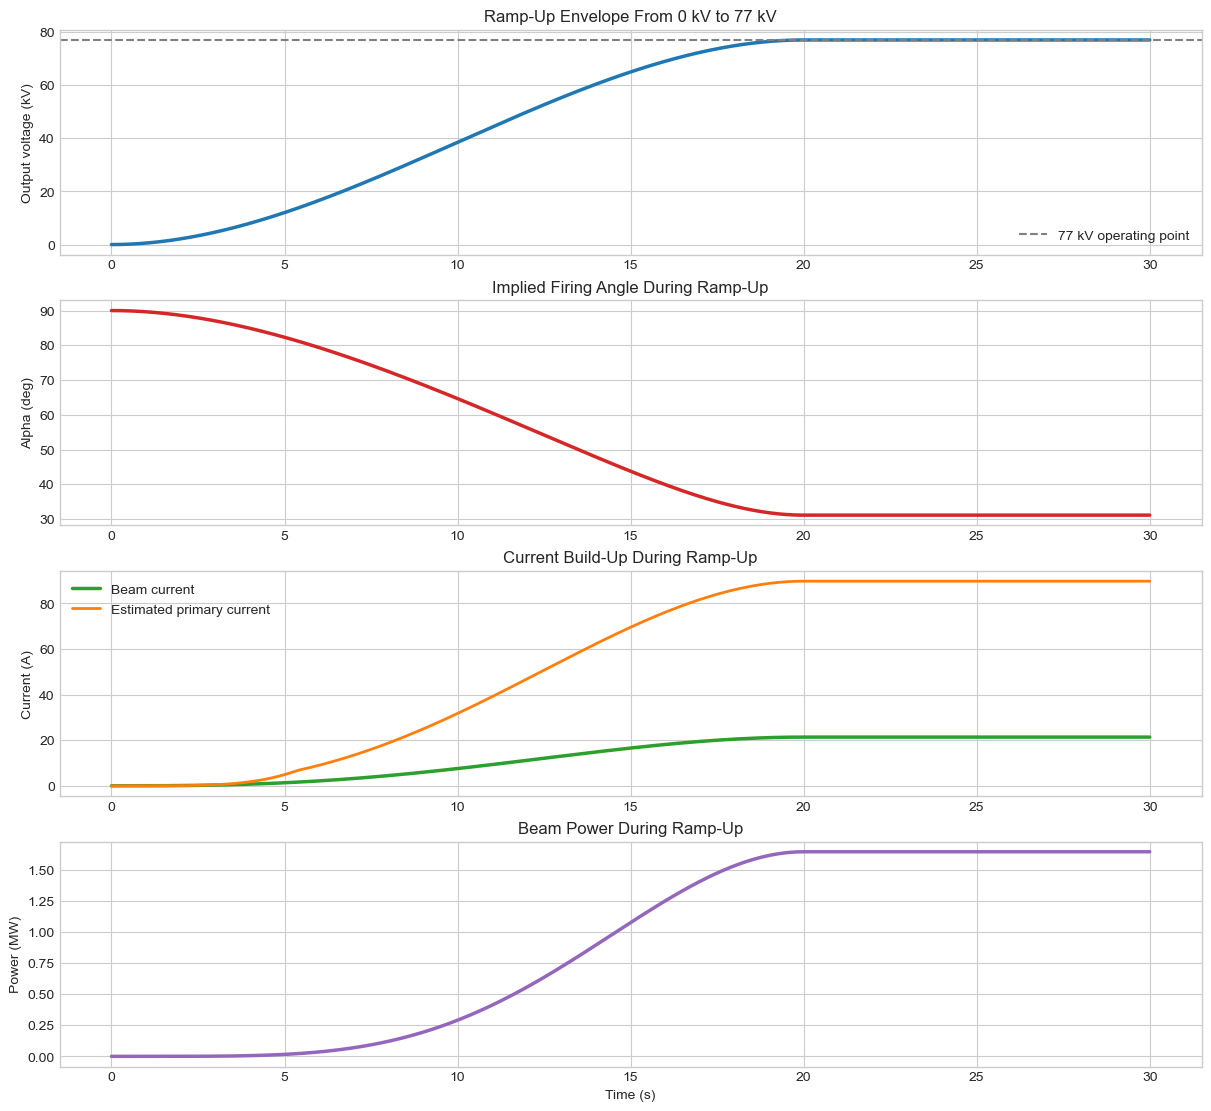

In [24]:
t_ramp = np.linspace(0, 30, 5000)
T_ramp = 20.0
x_ramp = np.clip(t_ramp / T_ramp, 0.0, 1.0)
smoothstep = 3 * x_ramp**2 - 2 * x_ramp**3
vdc_ramp = system['vdc_nominal'] * smoothstep
alpha_ramp = firing_angle_from_vdc(vdc_ramp, system['v_secondary_ll_rms'])
beam_current_ramp = beam_current_from_perveance(vdc_ramp)
beam_power_ramp = vdc_ramp * beam_current_ramp / 1e6
pf_ramp = np.clip(np.cos(alpha_ramp * DEG) * system['power_factor_distortion_12pulse'], 0.15, None)
primary_current_ramp = np.divide(
    vdc_ramp * beam_current_ramp,
    system['v_t1_primary_ll_rms'] * np.sqrt(3) * pf_ramp,
    out=np.zeros_like(vdc_ramp),
    where=pf_ramp > 0,
)

ramp_summary = pd.DataFrame({
    'Time_s': [0.0, 5.0, 10.0, 15.0, 20.0, 30.0],
})
ramp_summary['Vdc_kV'] = np.interp(ramp_summary['Time_s'], t_ramp, vdc_ramp) / 1e3
ramp_summary['Alpha_deg'] = np.interp(ramp_summary['Time_s'], t_ramp, alpha_ramp)
ramp_summary['BeamCurrent_A'] = np.interp(ramp_summary['Time_s'], t_ramp, beam_current_ramp)
ramp_summary['BeamPower_MW'] = np.interp(ramp_summary['Time_s'], t_ramp, beam_power_ramp)
ramp_summary['PrimaryCurrent_A'] = np.interp(ramp_summary['Time_s'], t_ramp, primary_current_ramp)
display(ramp_summary)

fig, axes = plt.subplots(4, 1, figsize=(12, 11), constrained_layout=True)
axes[0].plot(t_ramp, vdc_ramp / 1e3, linewidth=2.5, color='tab:blue')
axes[0].axhline(system['vdc_nominal'] / 1e3, linestyle='--', color='tab:gray', label='77 kV operating point')
axes[0].set_title('Ramp-Up Envelope From 0 kV to 77 kV')
axes[0].set_ylabel('Output voltage (kV)')
axes[0].legend()

axes[1].plot(t_ramp, alpha_ramp, linewidth=2.5, color='tab:red')
axes[1].set_title('Implied Firing Angle During Ramp-Up')
axes[1].set_ylabel('Alpha (deg)')

axes[2].plot(t_ramp, beam_current_ramp, linewidth=2.5, color='tab:green', label='Beam current')
axes[2].plot(t_ramp, primary_current_ramp, linewidth=2.0, color='tab:orange', label='Estimated primary current')
axes[2].set_title('Current Build-Up During Ramp-Up')
axes[2].set_ylabel('Current (A)')
axes[2].legend()

axes[3].plot(t_ramp, beam_power_ramp, linewidth=2.5, color='tab:purple')
axes[3].set_title('Beam Power During Ramp-Up')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('Power (MW)')
plt.show()

## 4B. Representative B118 Monitoring Channels

The current system documentation identifies four Building 118 monitoring channels used for troubleshooting and waveform observation:

1. HVPS output voltage
2. HVPS output current
3. Transformer 1 phase current
4. Inductor 2 diagnostic voltage

The following plots are representative engineering reconstructions of those channels. They are not archived oscilloscope captures. They are synthesized from the documented signal types, the 77 kV working point, the perveance-based load model, the estimated primary current, and the expected timing content of the rectifier and firing system.

Two views are useful:

- A long time-base view that shows how the four channels evolve through the startup ramp
- A short time-base view near steady operation that shows the waveform character of each monitored channel

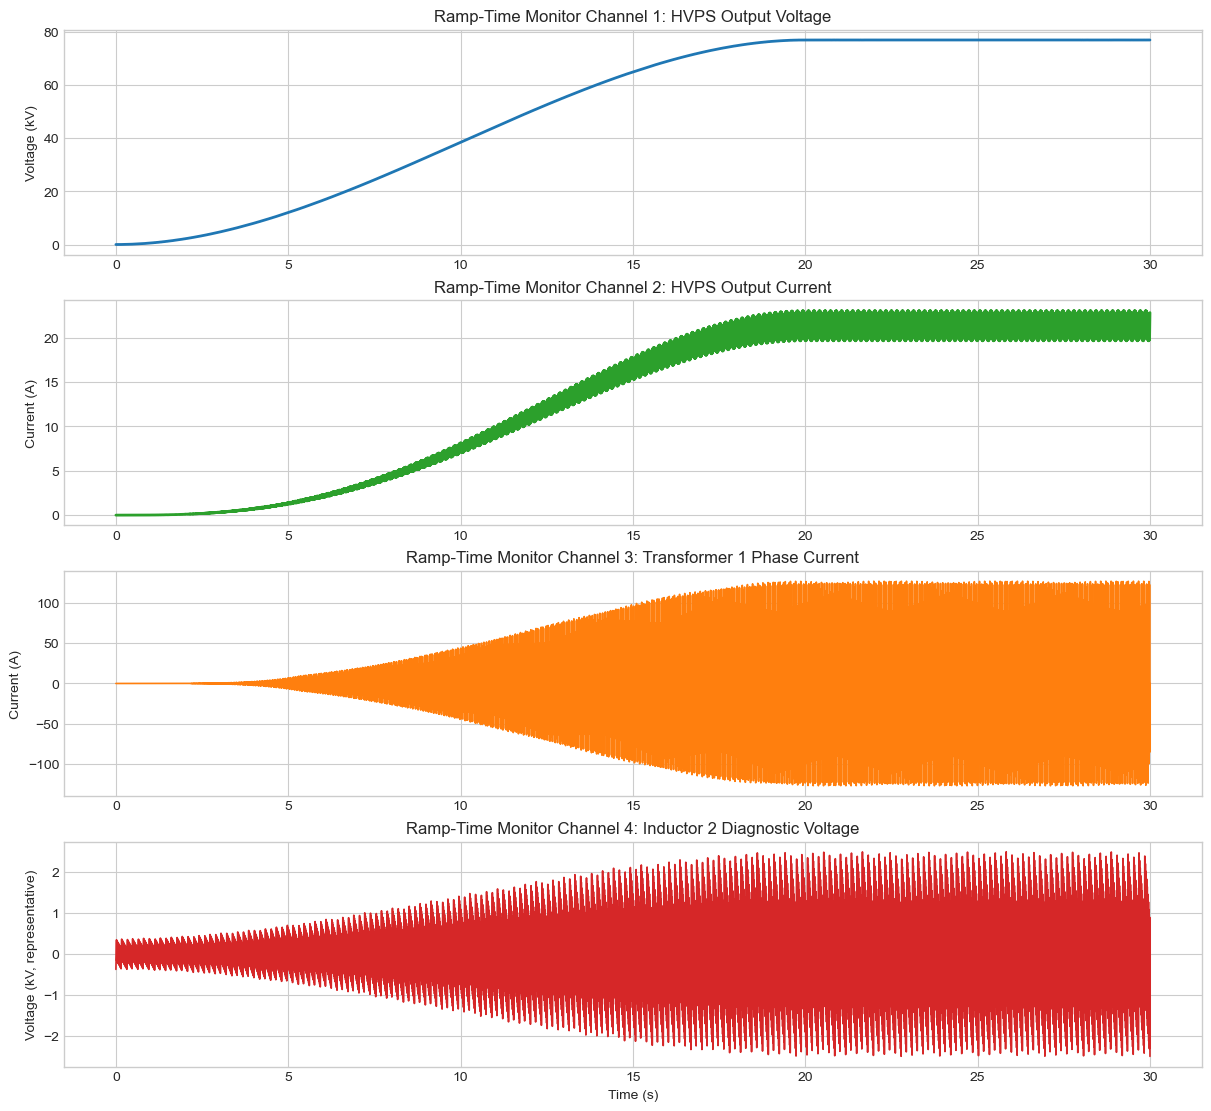

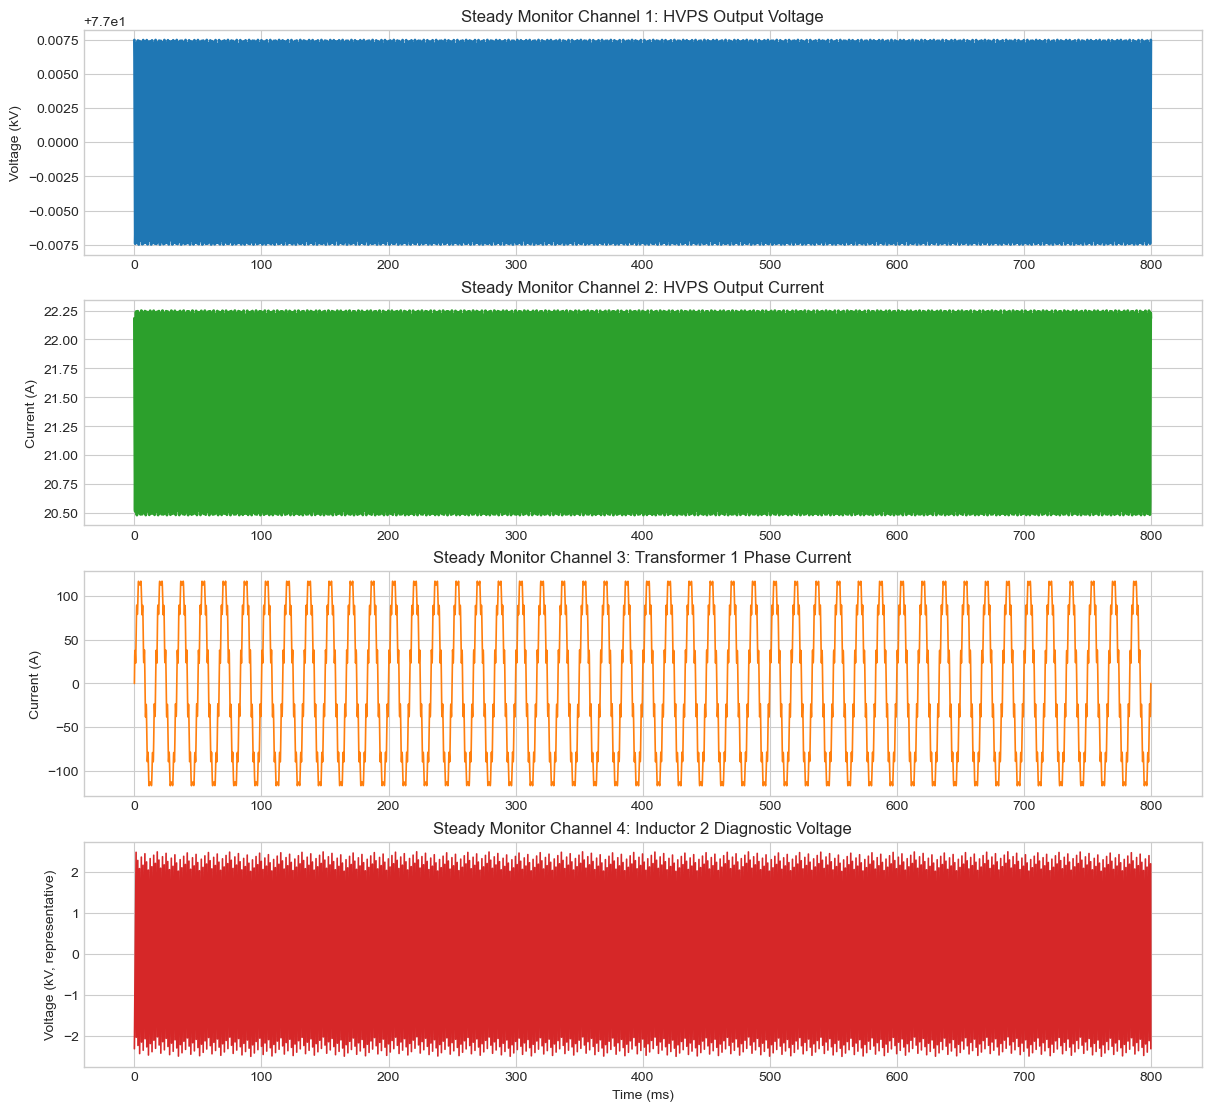

In [31]:
def sawtooth_wave(time_s, frequency_hz):
    phase = np.mod(time_s * frequency_hz, 1.0)
    return 2.0 * phase - 1.0

ripple_pp_fraction_local = 1.0 - np.cos(15 * DEG)
f_ripple_hz_local = 12 * system['f_line_hz']
f0_hz_local = 1.0 / (2 * np.pi * np.sqrt(1.07 * system['cap_filter_f']))
attenuation_ratio_local = (f_ripple_hz_local / f0_hz_local) ** 2
filtered_ripple_pp_local = ripple_pp_fraction_local * system['vdc_nominal'] / attenuation_ratio_local
nominal_beam_power_w = system['vdc_nominal'] * system['idc_nominal']
primary_current_nominal = nominal_beam_power_w / (system['v_t1_primary_ll_rms'] * np.sqrt(3) * 0.95)

monitor_voltage_ramp = vdc_ramp + 0.5 * filtered_ripple_pp_local * np.cos(2 * np.pi * f_ripple_hz_local * t_ramp)
monitor_current_ramp = beam_current_ramp + 0.08 * np.maximum(beam_current_ramp, 1e-9) * np.cos(2 * np.pi * f_ripple_hz_local * t_ramp + np.pi / 6)
monitor_current_ramp = np.maximum(monitor_current_ramp, 0.0)
phase_current_base = primary_current_ramp * np.sqrt(2)
monitor_t1_current_ramp = phase_current_base * (
    np.sin(2 * np.pi * system['f_line_hz'] * t_ramp)
    + 0.10 * np.sin(2 * np.pi * 11 * system['f_line_hz'] * t_ramp)
    + 0.08 * np.sin(2 * np.pi * 13 * system['f_line_hz'] * t_ramp)
)
inductor2_envelope = 0.15 + 0.85 * (vdc_ramp / system['vdc_nominal'])
monitor_l2_voltage_ramp = 2.5e3 * inductor2_envelope * sawtooth_wave(t_ramp, 12 * system['f_line_hz'])

fig, axes = plt.subplots(4, 1, figsize=(12, 11), constrained_layout=True)
axes[0].plot(t_ramp, monitor_voltage_ramp / 1e3, color='tab:blue', linewidth=2.0)
axes[0].set_title('Ramp-Time Monitor Channel 1: HVPS Output Voltage')
axes[0].set_ylabel('Voltage (kV)')

axes[1].plot(t_ramp, monitor_current_ramp, color='tab:green', linewidth=2.0)
axes[1].set_title('Ramp-Time Monitor Channel 2: HVPS Output Current')
axes[1].set_ylabel('Current (A)')

axes[2].plot(t_ramp, monitor_t1_current_ramp, color='tab:orange', linewidth=1.2)
axes[2].set_title('Ramp-Time Monitor Channel 3: Transformer 1 Phase Current')
axes[2].set_ylabel('Current (A)')

axes[3].plot(t_ramp, monitor_l2_voltage_ramp / 1e3, color='tab:red', linewidth=1.2)
axes[3].set_title('Ramp-Time Monitor Channel 4: Inductor 2 Diagnostic Voltage')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('Voltage (kV, representative)')
plt.show()

steady_window_s = 0.80
steady_samples = 6000
t_steady = np.linspace(0, steady_window_s, steady_samples)
vdc_steady = system['vdc_nominal'] + 0.5 * filtered_ripple_pp_local * np.cos(2 * np.pi * f_ripple_hz_local * t_steady)
idc_steady = beam_current_from_perveance(np.maximum(vdc_steady, 0.0)) + 0.04 * system['idc_nominal'] * np.cos(2 * np.pi * f_ripple_hz_local * t_steady + np.pi / 8)
it1_steady = np.sqrt(2) * primary_current_nominal * (
    np.sin(2 * np.pi * system['f_line_hz'] * t_steady)
    + 0.10 * np.sin(2 * np.pi * 11 * system['f_line_hz'] * t_steady)
    + 0.08 * np.sin(2 * np.pi * 13 * system['f_line_hz'] * t_steady)
)
l2_steady = 2.5e3 * sawtooth_wave(t_steady + alpha_nom / 360.0 / system['f_line_hz'], 12 * system['f_line_hz'])

fig, axes = plt.subplots(4, 1, figsize=(12, 11), constrained_layout=True)
axes[0].plot(t_steady * 1e3, vdc_steady/1e3, color='tab:blue', linewidth=2.0)
axes[0].set_title('Steady Monitor Channel 1: HVPS Output Voltage')
axes[0].set_ylabel('Voltage (kV)')

axes[1].plot(t_steady * 1e3, idc_steady, color='tab:green', linewidth=2.0)
axes[1].set_title('Steady Monitor Channel 2: HVPS Output Current')
axes[1].set_ylabel('Current (A)')

axes[2].plot(t_steady * 1e3, it1_steady, color='tab:orange', linewidth=1.2)
axes[2].set_title('Steady Monitor Channel 3: Transformer 1 Phase Current')
axes[2].set_ylabel('Current (A)')

axes[3].plot(t_steady * 1e3, l2_steady / 1e3, color='tab:red', linewidth=1.2)
axes[3].set_title('Steady Monitor Channel 4: Inductor 2 Diagnostic Voltage')
axes[3].set_xlabel('Time (ms)')
axes[3].set_ylabel('Voltage (kV, representative)')
plt.show()

## 5. Load Model, Beam Perveance, and Power

The document models the klystron beam current with a Child-Langmuir style perveance law using approximately $1.0 \times 10^{-6}$ A/V$^{3/2}$. This section reproduces the current, power, and effective impedance curves across operating voltage.

,V_cathode_kV,I_beam_A,P_beam_MW,R_eff_kOhm
0,60.0000,14.6969,0.8818,4.0825
1,65.0000,16.5718,1.0772,3.9223
2,70.0000,18.5203,1.2964,3.7796
3,72.0800,19.3518,1.3949,3.7247
4,77.0000,21.3666,1.6452,3.6037
5,80.0000,22.6274,1.8102,3.5355
6,85.0000,24.7815,2.1064,3.4300
7,90.0000,27.0000,2.4300,3.3333


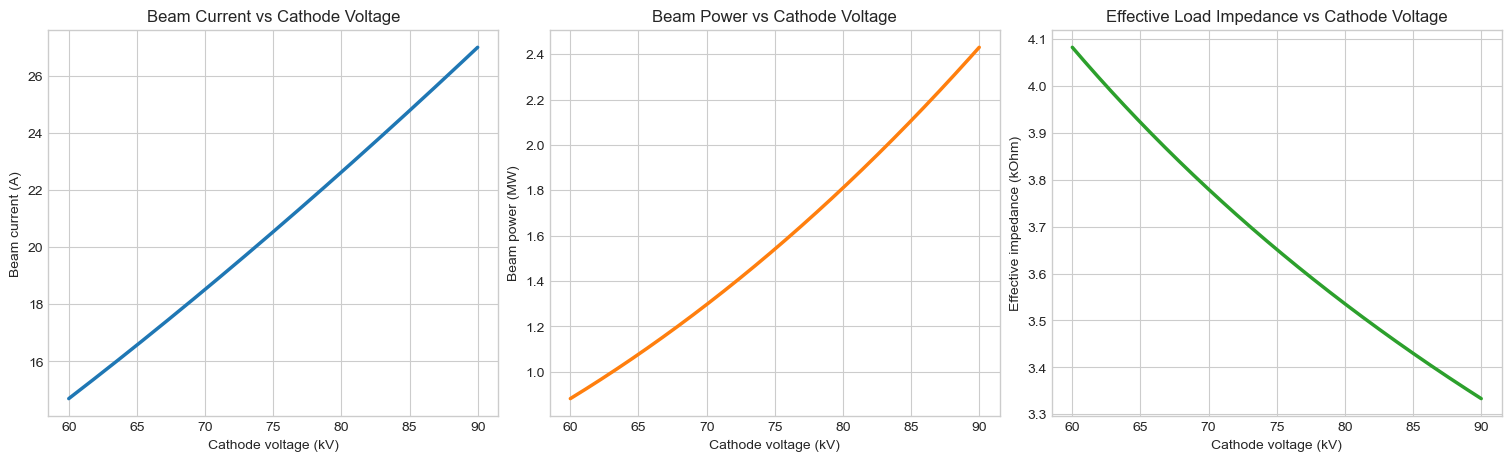

In [26]:
vdc_sweep = np.linspace(60e3, 90e3, 400)
beam_current = beam_current_from_perveance(vdc_sweep)
beam_power_mw = vdc_sweep * beam_current / 1e6
effective_impedance_kohm = (vdc_sweep / beam_current) / 1e3

sample_vdc = np.array([60, 65, 70, 72.08, 77, 80, 85, 90]) * 1e3
sample_idc = beam_current_from_perveance(sample_vdc)
sample_table = pd.DataFrame({
    'V_cathode_kV': sample_vdc / 1e3,
    'I_beam_A': sample_idc,
    'P_beam_MW': sample_vdc * sample_idc / 1e6,
    'R_eff_kOhm': (sample_vdc / sample_idc) / 1e3,
})
display(sample_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
axes[0].plot(vdc_sweep / 1e3, beam_current, linewidth=2.5)
axes[0].set_title('Beam Current vs Cathode Voltage')
axes[0].set_xlabel('Cathode voltage (kV)')
axes[0].set_ylabel('Beam current (A)')

axes[1].plot(vdc_sweep / 1e3, beam_power_mw, linewidth=2.5, color='tab:orange')
axes[1].set_title('Beam Power vs Cathode Voltage')
axes[1].set_xlabel('Cathode voltage (kV)')
axes[1].set_ylabel('Beam power (MW)')

axes[2].plot(vdc_sweep / 1e3, effective_impedance_kohm, linewidth=2.5, color='tab:green')
axes[2].set_title('Effective Load Impedance vs Cathode Voltage')
axes[2].set_xlabel('Cathode voltage (kV)')
axes[2].set_ylabel('Effective impedance (kOhm)')
plt.show()

## 6. Ripple Geometry and LC Filter Attenuation

The report connects the unfiltered ripple directly to the 30 degree cosine arcs and then estimates attenuation using the reflected filter inductance and the 8 uF capacitor bank. This section reproduces both the geometric ripple estimate and the frequency-domain attenuation estimate.

,Metric,Value
0,Unfiltered ripple fraction,0.0341
1,Unfiltered ripple at 77 kV (Vpp),"2,623.7114"
2,Ripple frequency (Hz),720.0000
3,Filter resonance (Hz),54.3980
4,Attenuation ratio,175.1856
5,Filtered ripple (Vpp),14.9767
6,Filtered ripple (Vrms),5.2951


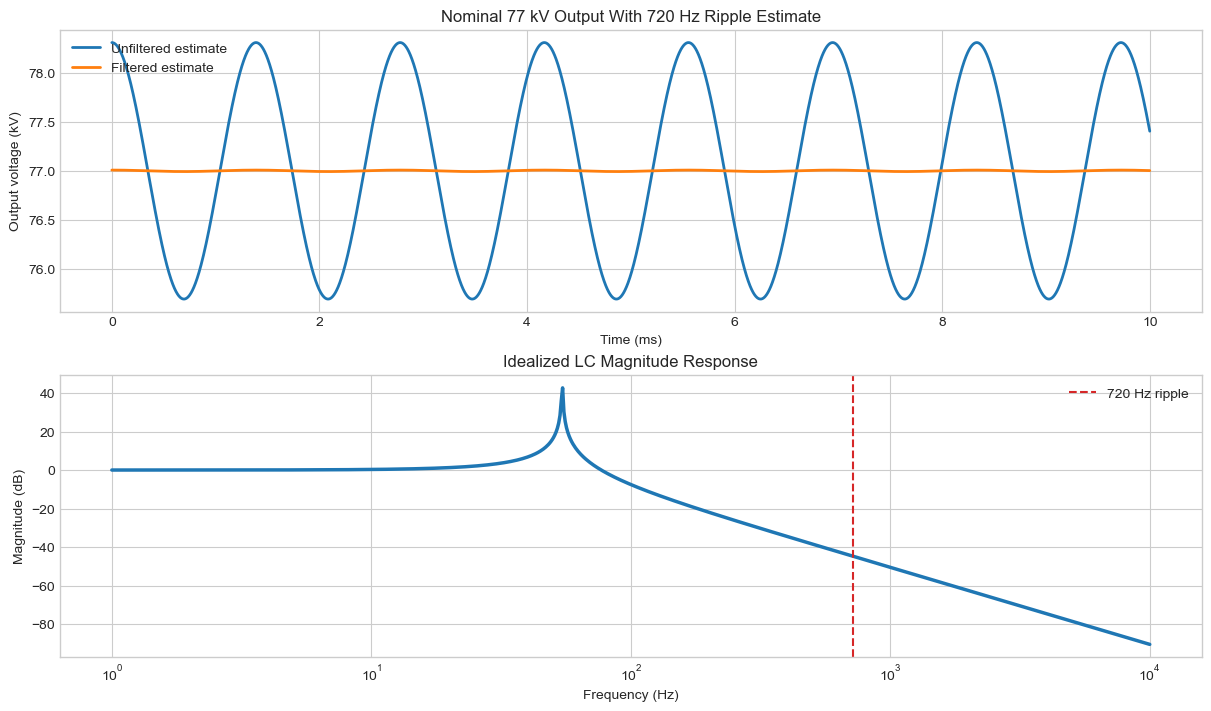

In [27]:
ripple_pp_fraction_geom = 1.0 - np.cos(15 * DEG)
ripple_pp_nominal_volts = ripple_pp_fraction_geom * system['vdc_nominal']

l_secondary_effective_h = 1.07
f_ripple_hz = 12 * system['f_line_hz']
f0_hz = 1.0 / (2 * np.pi * np.sqrt(l_secondary_effective_h * system['cap_filter_f']))
attenuation_ratio = (f_ripple_hz / f0_hz) ** 2
filtered_ripple_pp_volts = ripple_pp_nominal_volts / attenuation_ratio
filtered_ripple_rms_volts = filtered_ripple_pp_volts / (2 * np.sqrt(2))

ripple_summary = pd.DataFrame({
    'Metric': [
        'Unfiltered ripple fraction',
        'Unfiltered ripple at 77 kV (Vpp)',
        'Ripple frequency (Hz)',
        'Filter resonance (Hz)',
        'Attenuation ratio',
        'Filtered ripple (Vpp)',
        'Filtered ripple (Vrms)',
    ],
    'Value': [
        ripple_pp_fraction_geom,
        ripple_pp_nominal_volts,
        f_ripple_hz,
        f0_hz,
        attenuation_ratio,
        filtered_ripple_pp_volts,
        filtered_ripple_rms_volts,
    ]
})
display(ripple_summary)

time_ms = np.linspace(0, 10, 4000)
unfiltered_ripple = system['vdc_nominal'] + 0.5 * ripple_pp_nominal_volts * np.cos(2 * np.pi * f_ripple_hz * time_ms / 1e3)
filtered_ripple = system['vdc_nominal'] + 0.5 * filtered_ripple_pp_volts * np.cos(2 * np.pi * f_ripple_hz * time_ms / 1e3)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
axes[0].plot(time_ms, unfiltered_ripple / 1e3, linewidth=2, label='Unfiltered estimate')
axes[0].plot(time_ms, filtered_ripple / 1e3, linewidth=2, label='Filtered estimate')
axes[0].set_title('Nominal 77 kV Output With 720 Hz Ripple Estimate')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Output voltage (kV)')
axes[0].legend()

freq = np.logspace(0, 4, 800)
lc_gain = 1.0 / np.sqrt((1 - (freq / f0_hz) ** 2) ** 2 + 1e-12)
axes[1].semilogx(freq, 20 * np.log10(lc_gain), linewidth=2.5)
axes[1].axvline(f_ripple_hz, color='tab:red', linestyle='--', label='720 Hz ripple')
axes[1].set_title('Idealized LC Magnitude Response')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].legend()
plt.show()

## 7. Protection Energy and Discharge Models

The analytical section distinguishes between total capacitor stored energy and the simplified RC branch discharge through the 500 ohm isolation path. It also quantifies primary inductor energy and the cable-inductor current slew limit.

,Time_ms,RC branch current_A,Released energy_J,Released energy_pct
0,0.0010,153.9615,11.8550,0.0500
1,0.0100,153.6155,118.2840,0.4988
2,0.1000,150.1977,"1,156.6430",4.8771
3,1.0000,119.9353,"9,331.5189",39.3469
4,2.0000,93.4057,"14,991.3712",63.2121
5,4.0000,56.6534,"20,506.3884",86.4665


Capacitor stored energy at 77 kV: 23,716.0 J
Initial RC branch current: 154.0 A
Inductor energy at rated 85 A: 1,083.8 J per inductor
Estimated primary current at measured operating point: 68.0 A
Inductor energy at measured operating point: 693.3 J per inductor
Cable inductor current slew limit: 385.0 A/us
Lumped RC I^2 t estimate: 47.4 A^2 s


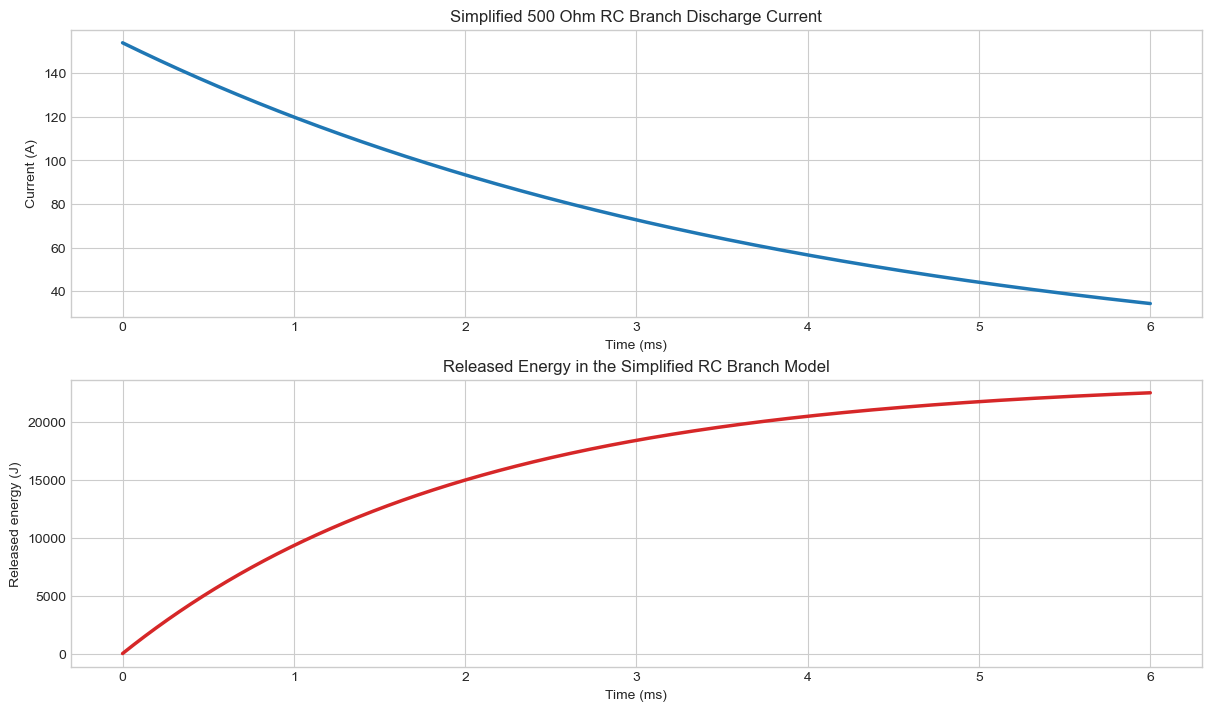

In [28]:
c_filter = system['cap_filter_f']
r_iso = system['isolation_res_ohm']
tau_rc_s = r_iso * c_filter
e_cap_j = 0.5 * c_filter * system['vdc_nominal'] ** 2
i_branch_peak_a = system['vdc_nominal'] / r_iso

times_s = np.array([1e-6, 10e-6, 0.1e-3, 1e-3, 2e-3, tau_rc_s])
i_branch = i_branch_peak_a * np.exp(-times_s / tau_rc_s)
e_released = e_cap_j * (1 - np.exp(-2 * times_s / tau_rc_s))

power_estimate_w = system['vdc_measured'] * system['idc_measured']
i_primary_operating_a = power_estimate_w / (system['v_t1_primary_ll_rms'] * np.sqrt(3) * 0.95)
e_inductor_operating_j = 0.5 * system['inductor_primary_h'] * i_primary_operating_a ** 2
e_inductor_rated_j = 0.5 * system['inductor_primary_h'] * system['inductor_primary_rated_a'] ** 2
di_dt_limit_a_per_us = (system['vdc_nominal'] / system['cable_inductor_h']) / 1e6
i2t_estimate = ((system['vdc_nominal'] / r_iso) ** 2) * (tau_rc_s / 2)

protection_table = pd.DataFrame({
    'Time_ms': times_s * 1e3,
    'RC branch current_A': i_branch,
    'Released energy_J': e_released,
    'Released energy_pct': 100 * e_released / e_cap_j,
})
display(protection_table)
print(f'Capacitor stored energy at 77 kV: {e_cap_j:,.1f} J')
print(f'Initial RC branch current: {i_branch_peak_a:,.1f} A')
print(f'Inductor energy at rated 85 A: {e_inductor_rated_j:,.1f} J per inductor')
print(f'Estimated primary current at measured operating point: {i_primary_operating_a:,.1f} A')
print(f'Inductor energy at measured operating point: {e_inductor_operating_j:,.1f} J per inductor')
print(f'Cable inductor current slew limit: {di_dt_limit_a_per_us:,.1f} A/us')
print(f'Lumped RC I^2 t estimate: {i2t_estimate:,.1f} A^2 s')

t_discharge_ms = np.linspace(0, 6, 2500)
current_discharge = i_branch_peak_a * np.exp(-(t_discharge_ms / 1e3) / tau_rc_s)
energy_discharge = e_cap_j * (1 - np.exp(-2 * (t_discharge_ms / 1e3) / tau_rc_s))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
axes[0].plot(t_discharge_ms, current_discharge, linewidth=2.5)
axes[0].set_title('Simplified 500 Ohm RC Branch Discharge Current')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Current (A)')

axes[1].plot(t_discharge_ms, energy_discharge, linewidth=2.5, color='tab:red')
axes[1].set_title('Released Energy in the Simplified RC Branch Model')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Released energy (J)')
plt.show()

## 8. Power Factor and Harmonic Content

The report uses displacement power factor $\cos(\alpha)$ multiplied by an idealized 12-pulse distortion factor of about 0.9886. It also lists the dominant non-cancelled harmonics as orders 11, 13, 23, 25, 35, and 37.

,Harmonic_order,Relative_magnitude,Frequency_Hz
0,11,0.0909,660.0000
1,13,0.0769,780.0000
2,23,0.0435,"1,380.0000"
3,25,0.0400,"1,500.0000"
4,35,0.0286,"2,100.0000"
5,37,0.0270,"2,220.0000"


Idealized THD estimate through 37th harmonic: 13.86%


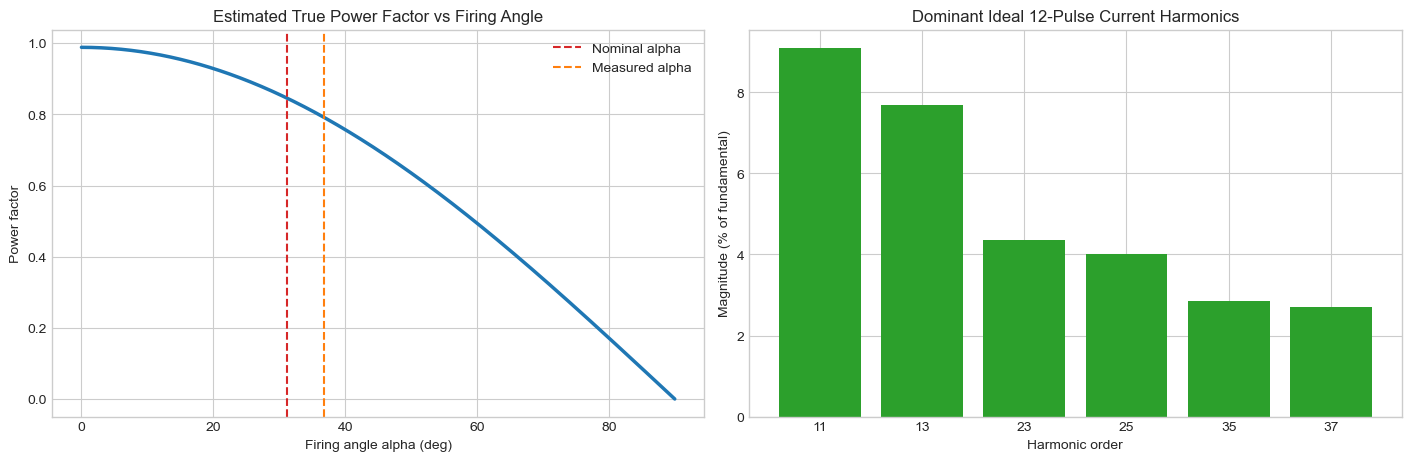

In [29]:
pf_curve = np.cos(alpha_deg * DEG) * system['power_factor_distortion_12pulse']
harmonics = harmonic_orders_12pulse(37)
harmonic_magnitude = 1.0 / harmonics
thd_estimate = np.sqrt(np.sum(harmonic_magnitude ** 2))

harmonic_table = pd.DataFrame({
    'Harmonic_order': harmonics,
    'Relative_magnitude': harmonic_magnitude,
    'Frequency_Hz': harmonics * system['f_line_hz'],
})
display(harmonic_table)
print(f'Idealized THD estimate through 37th harmonic: {100 * thd_estimate:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
axes[0].plot(alpha_deg, pf_curve, linewidth=2.5)
axes[0].axvline(alpha_nom, linestyle='--', color='tab:red', label='Nominal alpha')
axes[0].axvline(alpha_meas, linestyle='--', color='tab:orange', label='Measured alpha')
axes[0].set_title('Estimated True Power Factor vs Firing Angle')
axes[0].set_xlabel('Firing angle alpha (deg)')
axes[0].set_ylabel('Power factor')
axes[0].legend()

axes[1].bar(harmonics.astype(str), 100 * harmonic_magnitude, color='tab:green')
axes[1].set_title('Dominant Ideal 12-Pulse Current Harmonics')
axes[1].set_xlabel('Harmonic order')
axes[1].set_ylabel('Magnitude (% of fundamental)')
plt.show()

## 9. Consolidated Design Summary

This final cell gathers the main numerical outputs so the notebook can serve as a quick engineering reference alongside the report.

In [30]:
summary = pd.DataFrame({
    'Parameter': [
        '12-pulse DC coefficient',
        'Secondary LL voltage for 90 kV max',
        'Transformer turns ratio',
        'Nominal alpha at 77 kV',
        'Measured alpha at 72.08 kV',
        'Ripple frequency',
        'LC resonance estimate',
        'Unfiltered ripple fraction',
        'Filtered ripple at 77 kV (Vpp)',
        'Capacitor stored energy at 77 kV',
        'Cable current slew limit',
        'Idealized PF at nominal alpha',
    ],
    'Value': [
        6 * np.sqrt(2) / np.pi,
        system['v_secondary_ll_rms'] / 1e3,
        turns_ratio,
        alpha_nom,
        alpha_meas,
        f_ripple_hz,
        f0_hz,
        ripple_pp_fraction_geom,
        filtered_ripple_pp_volts,
        e_cap_j,
        di_dt_limit_a_per_us,
        np.cos(alpha_nom * DEG) * system['power_factor_distortion_12pulse'],
    ],
    'Units': [
        'Vdc / V_LL',
        'kV RMS',
        ':1',
        'deg',
        'deg',
        'Hz',
        'Hz',
        'fraction',
        'Vpp',
        'J',
        'A/us',
        'fraction',
    ]
})
display(summary)

,Parameter,Value,Units
0,12-pulse DC coefficient,2.7009,Vdc / V_LL
1,Secondary LL voltage for 90 kV max,33.3000,kV RMS
2,Transformer turns ratio,2.6640,:1
3,Nominal alpha at 77 kV,31.1173,deg
4,Measured alpha at 72.08 kV,36.7351,deg
5,Ripple frequency,720.0000,Hz
6,LC resonance estimate,54.3980,Hz
7,Unfiltered ripple fraction,0.0341,fraction
8,Filtered ripple at 77 kV (Vpp),14.9767,Vpp
9,Capacitor stored energy at 77 kV,"23,716.0000",J
